In [ ]:
"""This code builds and compares simple and multiple linear regression models to predict food delivery time based on features like distance, preparation time, and courier experience.
It also visualizes relationships, evaluates model performance (MSE, R²), and determines which model fits the data better."""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [56]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [57]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [58]:
print("All columns in dataset:")
print(df.columns.tolist())

All columns in dataset:
['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


In [59]:
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

In [60]:
print("\nPredictor Variables:\n", X.columns.tolist())
print("\nDependent Variable:\n", 'Delivery_Time_min')


Predictor Variables:
 ['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']

Dependent Variable:
 Delivery_Time_min


In [61]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [62]:
df = df.fillna(df.mean(numeric_only=True))

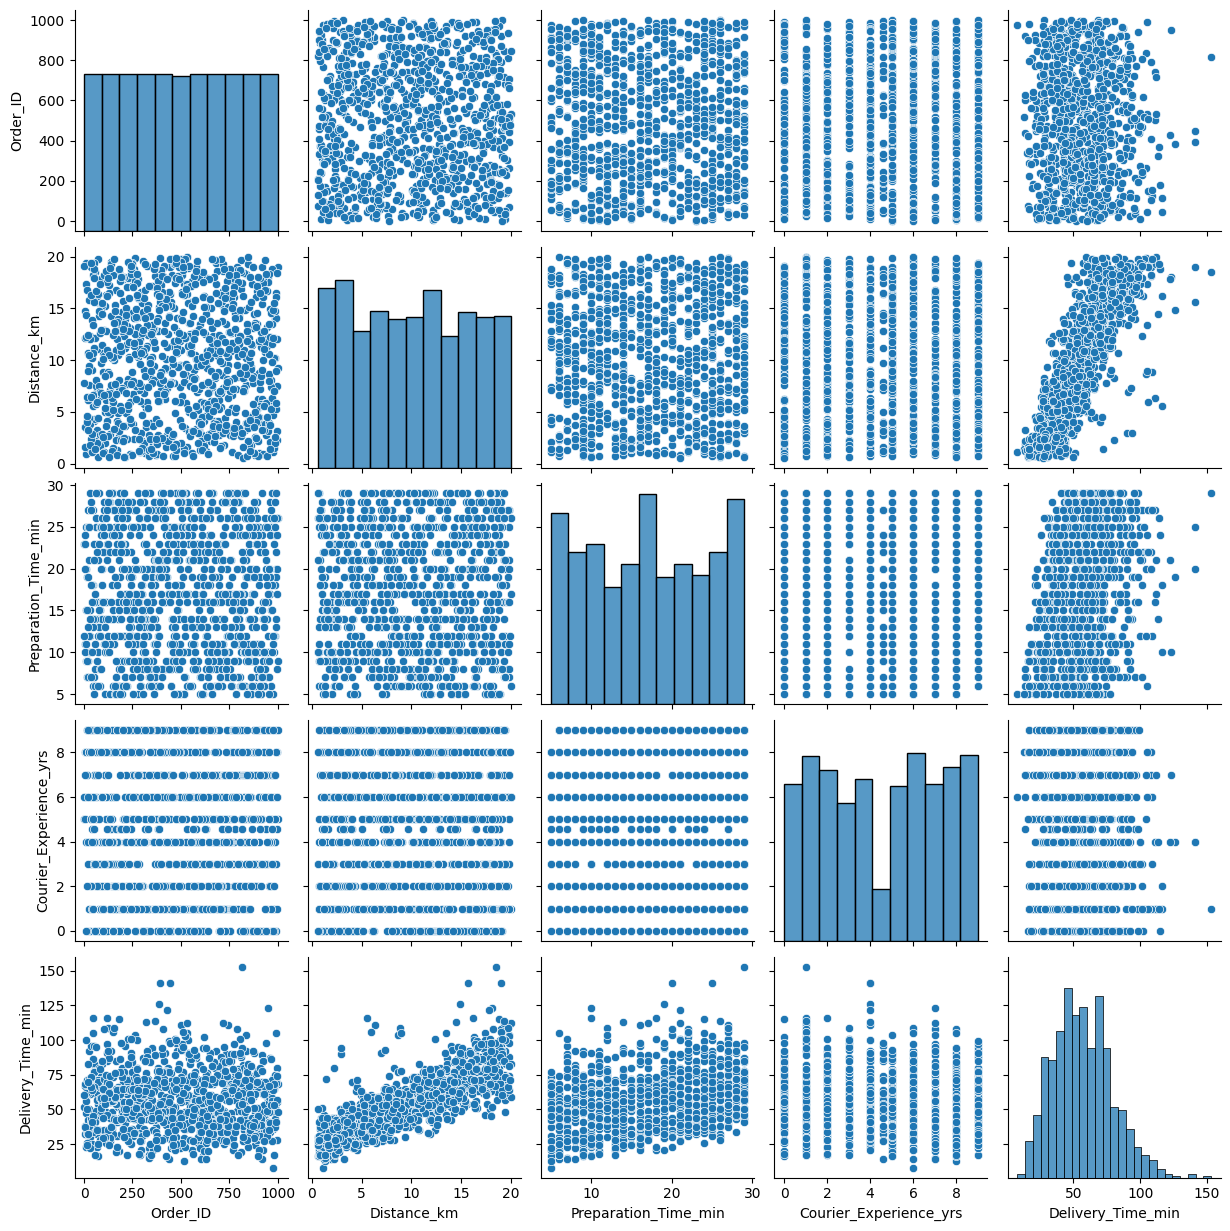

In [63]:
sns.pairplot(df)
plt.show()

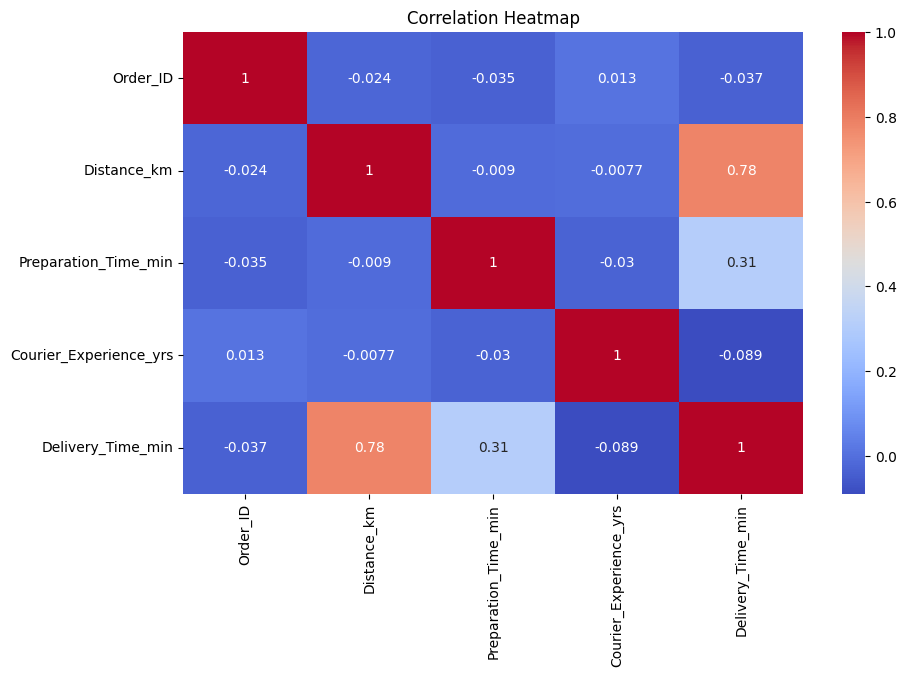

In [80]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [65]:
X_simple = df[['Distance_km']]
y = df['Delivery_Time_min']

In [66]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

In [67]:
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

LinearRegression()

In [68]:
y_pred_s = model_simple.predict(X_test_s)

In [69]:
mse_simple = mean_squared_error(y_test_s, y_pred_s)
r2_simple = r2_score(y_test_s, y_pred_s)

In [70]:
print("Simple Linear Regression:")
print("MSE:", mse_simple)
print("R^2 Score:", r2_simple)

Simple Linear Regression:
MSE: 158.16196727280166
R^2 Score: 0.6471386683659509


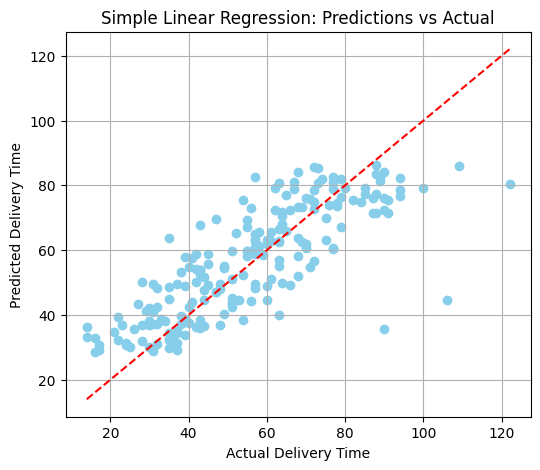

In [71]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test_s, y_pred_s, color='skyblue')
plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], 'r--')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Simple Linear Regression: Predictions vs Actual")
plt.grid(True)
plt.show()


In [72]:
X = df[['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']]
y = df['Delivery_Time_min']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

LinearRegression()

In [75]:
y_pred_m = model_multiple.predict(X_test)

In [76]:
mse_multiple = mean_squared_error(y_test, y_pred_m)
r2_multiple = r2_score(y_test, y_pred_m)

In [77]:

print("Multiple Linear Regression:")
print("MSE:", mse_multiple)
print("R^2 Score:", r2_multiple)

Multiple Linear Regression:
MSE: 119.68103345773156
R^2 Score: 0.7329901140873292


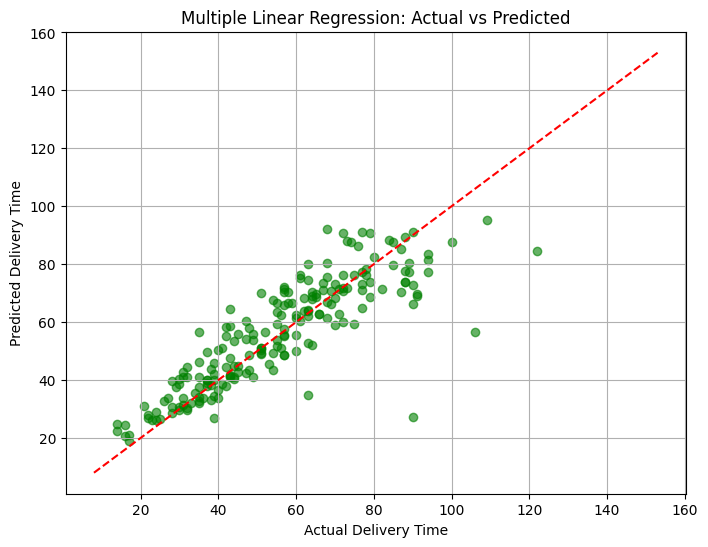

In [78]:
# Plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_m, color='green', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


In [79]:
print("\nModel Comparison:")
print(f"Simple Linear Regression MSE: {mse_simple}")
print(f"Multiple Linear Regression MSE: {mse_multiple}")

if mse_multiple < mse_simple:
    print("Multiple linear regression is better")
else:
    print("Simple linear regression is better")



Model Comparison:
Simple Linear Regression MSE: 158.16196727280166
Multiple Linear Regression MSE: 119.68103345773156
Multiple linear regression is better


In [ ]:
"""1. import pandas as pd
Imports the pandas library for data manipulation and reading CSV files.

2. import numpy as np
Imports numpy for numerical operations and data handling.

3. import matplotlib.pyplot as plt
Used to plot visual graphs like scatter plots and line charts.

4. import seaborn as sns
Imports seaborn for advanced data visualizations like heatmaps and pair plots.

5. from sklearn.model_selection import train_test_split
Loads function to split dataset into training and testing sets.

6. from sklearn.linear_model import LinearRegression
Imports the linear regression model for building both simple and multiple regression models.

7. from sklearn.metrics import mean_squared_error, r2_score
Imports performance metrics: MSE (error measure) and R² score (goodness of fit).

8. df = pd.read_csv('Food_Delivery_Times.csv')
Loads the dataset named Food_Delivery_Times.csv into a DataFrame df.

9. df.head()
Displays the first 5 rows of the dataset.

10. print("All columns in dataset:")
Prints label to indicate the following output shows column names.

11. print(df.columns.tolist())
Lists all column names from the dataset.

12. X = df.drop('Delivery_Time_min', axis=1)
Defines the predictor variables (features) by dropping the target column.

13. y = df['Delivery_Time_min']
Defines the dependent variable (target) as delivery time in minutes.

14. print("\nPredictor Variables:\n", X.columns.tolist())
Prints all predictor variable names.

15. print("\nDependent Variable:\n", 'Delivery_Time_min')
Prints the name of the target variable.

16. print("Missing values in each column:")
Label for upcoming output about null values.

17. print(df.isnull().sum())
Shows the number of missing values per column.

18. df = df.fillna(df.mean(numeric_only=True))
Fills missing numeric values with their respective column means.

19. sns.pairplot(df)
Creates pairwise scatterplots to explore relationships between all variables.

20. plt.show()
Displays the pairplot chart.

🔥 Correlation Heatmap
21. numeric_df = df.select_dtypes(include=['int64', 'float64'])
Selects only numeric columns for correlation analysis.

22. plt.figure(figsize=(10, 6))
Sets figure size for the heatmap.

23. sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
Plots a heatmap of correlation values between numeric columns.

24. plt.title("Correlation Heatmap")
Sets the heatmap title.

25. plt.show()
Displays the heatmap.

📉 Simple Linear Regression: Only 'Distance_km'
26. X_simple = df[['Distance_km']]
Uses only the 'Distance_km' column as input (feature).

27. y = df['Delivery_Time_min']
Defines target variable again for clarity.

28. X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)
Splits data into training and testing sets (80/20 split).

29. model_simple = LinearRegression()
Initializes the simple linear regression model.

30. model_simple.fit(X_train_s, y_train_s)
Trains the model using training data.

31. y_pred_s = model_simple.predict(X_test_s)
Predicts delivery time for test inputs.

32. mse_simple = mean_squared_error(y_test_s, y_pred_s)
Calculates Mean Squared Error (MSE) for prediction.

33. r2_simple = r2_score(y_test_s, y_pred_s)
Calculates R² score to measure model accuracy.

34. print("Simple Linear Regression:")
Displays section heading.

35. print("MSE:", mse_simple)
Prints the MSE of simple regression.

36. print("R^2 Score:", r2_simple)
Prints the R² score of simple regression.

📊 Simple Linear Regression Plot
37. plt.figure(figsize=(6, 5))
Sets figure size.

38. plt.scatter(y_test_s, y_pred_s, color='skyblue')
Plots actual vs predicted values as a scatter plot.

39. plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], 'r--')
Plots a diagonal reference line representing perfect prediction.

40. plt.xlabel("Actual Delivery Time")
Labels X-axis.

41. plt.ylabel("Predicted Delivery Time")
Labels Y-axis.

42. plt.title("Simple Linear Regression: Predictions vs Actual")
Sets the plot title.

43. plt.grid(True)
Enables grid.

44. plt.show()
Displays the plot.

📈 Multiple Linear Regression
45. X = df[['Order_ID', 'Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']]
Uses four columns as features for multiple regression.

46. y = df['Delivery_Time_min']
Defines target again.

47. X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Splits data for multiple regression training/testing.

48. model_multiple = LinearRegression()
Initializes multiple linear regression model.

49. model_multiple.fit(X_train, y_train)
Trains the multiple regression model.

50. y_pred_m = model_multiple.predict(X_test)
Predicts test data delivery time.

51. mse_multiple = mean_squared_error(y_test, y_pred_m)
Calculates MSE of multiple regression.

52. r2_multiple = r2_score(y_test, y_pred_m)
Calculates R² score for multiple regression.

53. print("Multiple Linear Regression:")
Section heading.

54. print("MSE:", mse_multiple)
Prints MSE of multiple regression.

55. print("R^2 Score:", r2_multiple)
Prints R² score of multiple regression.

📉 Multiple Linear Regression Plot
56. plt.figure(figsize=(8, 6))
Sets figure size.

57. plt.scatter(y_test, y_pred_m, color='green', alpha=0.6)
Plots actual vs predicted for multiple regression.

58. plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
Plots ideal prediction line.

59. plt.xlabel("Actual Delivery Time")
Labels X-axis.

60. plt.ylabel("Predicted Delivery Time")
Labels Y-axis.

61. plt.title("Multiple Linear Regression: Actual vs Predicted")
Sets plot title.

62. plt.grid(True)
Enables grid.

63. plt.show()
Displays the plot.

⚖️ Model Comparison
64. print("\nModel Comparison:")
Prints section header.

65. print(f"Simple Linear Regression MSE: {mse_simple}")
Prints simple regression error.

66. print(f"Multiple Linear Regression MSE: {mse_multiple}")
Prints multiple regression error.

67. if mse_multiple < mse_simple:
Checks which model has lower MSE.

68. print("Multiple linear regression is better")
Outputs if multiple model is better.

69. else:
Fallback if simple model is better.

70. print("Simple linear regression is better")
Outputs if simple model performs better."""